# 03 — Feature Analysis & Feature Importance

**Kenya maize (One Acre Fund MEL Agronomic Survey, 2016–2020)**

This notebook is the analysis layer between the feature contract built by
`scripts/build_features.py` and the modelling package. It answers three
questions, in this order:

1. **What actually correlates with yield, and why?** Separating real agronomic
   signal from geographic and seasonal confounding, which in this dataset is
   the dominant effect and the easiest thing to get wrong.
2. **Which features carry predictive weight out-of-time?** Importance measured
   against the held-out 2020 season, not against the training years — because
   the two disagree sharply, and only one of them is the deployment condition.
3. **What is the best planting window?** The one genuinely ex-ante timing lever
   a farmer controls, quantified with district × season fixed effects.

### What this notebook establishes

| Finding | Consequence |
|---|---|
| The strongest raw correlates of yield are all **temperature**, at *r* ≈ −0.33 — but within a district they collapse to −0.06 | Temperature is an **altitude / agro-ecological-zone proxy**, not a driver. It predicts *where*, not *how much*. |
| `hybrid_seed_share`, `n_kg_ph` and `topdress_applied` hold their correlation within district | These are the real, controllable agronomic levers. |
| A naive ex-ante model scores **negative R² out-of-time** | Features whose variance is mostly *between seasons* memorize the year. Pruning them and capping tree depth moves ex-ante R² from **−0.040 to +0.123**. |
| Planting after ~day-of-year 90 costs yield monotonically | **−325 kg/ha** by day 120 versus a late-February optimum, after controlling for inputs; the penalty survives every control tried. |

> **Prerequisite.** Run `python scripts/build_features.py` first (and optionally the
> weather pipeline before it). This notebook only reads `data/features/`.

## 0 · Setup

In [30]:
import os, warnings, json
from pathlib import Path

# joblib probes physical core count with `wmic`, which is absent on recent
# Windows builds and dumps a traceback into every cell that touches sklearn.
os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(os.cpu_count() or 4))
import contextlib, io as _io
with contextlib.redirect_stderr(_io.StringIO()):   # warm the cache quietly
    try:
        from joblib.externals.loky.backend import context as _loky_ctx
        _loky_ctx._count_physical_cores()
    except Exception:
        pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

import lightgbm as lgb
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

# --- paths: walk up until data/features is visible, so the notebook runs from
# --- either the repo root or the notebooks/ directory.
ROOT = Path.cwd()
while not (ROOT / "data" / "features").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
FEATURES = ROOT / "data" / "features"
print("project root:", ROOT)

TARGET       = "yield_kg_ph"
HOLDOUT_YEAR = 2020
TRAIN_YEARS  = (2016, 2017, 2018, 2019)

# --- palette (validated: CVD dE 9.2, normal-vision dE 24.0, all-pairs, light mode)
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
RED, VIOLET        = "#e34948", "#4a3aa7"
INK, INK2, MUTED   = "#0b0b0b", "#52514e", "#b4b3ad"
SURFACE            = "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.labelsize": 10, "axes.labelcolor": INK2,
    "text.color": INK, "xtick.color": INK2, "ytick.color": INK2,
    "axes.edgecolor": MUTED, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": "#e6e5e0", "grid.linewidth": 0.8,
    "legend.frameon": False, "figure.dpi": 110,
})

def style(ax, title=None, xlabel=None, ylabel=None, xgrid=False, ygrid=True):
    """Recessive grid, grid behind the marks, optional labels."""
    if title:  ax.set_title(title, loc="left", pad=10)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    ax.grid(axis="y" if ygrid and not xgrid else "x" if xgrid else "y",
            visible=xgrid or ygrid)
    ax.set_axisbelow(True)
    return ax

project root: c:\Users\Administrator\Desktop\yield-prediction-and-agronomic-recomendation


In [31]:
def restore_dtypes(df):
    """CSV has no dtype system. The feature pipeline emits pandas `boolean`
    columns, which round-trip as the *strings* "True"/"False" — pandas then
    guesses `bool` for the columns with no missing values and `object` for the
    ones with missing values. Left alone, that inconsistency silently breaks
    any operation applied uniformly across the boolean block. Cast every such
    column to float (1/0/NaN) so correlations and GBMs both see the same thing.
    """
    for c in df.columns:
        if df[c].dtype == bool:
            df[c] = df[c].astype(float)
        elif df[c].dtype == object:
            vals = set(df[c].dropna().unique())
            if vals and vals <= {True, False, "True", "False"}:
                df[c] = df[c].map({True: 1.0, False: 0.0,
                                   "True": 1.0, "False": 0.0}).astype(float)
    return df

full     = restore_dtypes(pd.read_csv(FEATURES / "kenya_maize_features_full.csv",
                                      low_memory=False))
manifest = pd.read_csv(FEATURES / "kenya_maize_feature_manifest.csv")

# The contract: only columns the pipeline marked `keep` are live features in the
# full (2016-2020) file. `keep_core_only` columns exist solely in the core file,
# which trades 2016's rows for ~13 extra columns; they are excluded here so that
# every number below refers to one consistent row set.
contract = manifest[manifest.decision == "keep"].set_index("feature")
FEATS    = [c for c in contract.index if c in full.columns]
YVS      = contract["year_variance_share"]   # share of variance BETWEEN years
ROLE     = contract["role"]
TIER     = contract["availability_tier"]

CATEGORICAL = [c for c in ["district", "seed_category", "seed_type",
                           "seed_type_clean", "seed_type_primary",
                           "intercrop_type"] if c in FEATS]
for c in CATEGORICAL:
    full[c] = full[c].astype("category")

NUMERIC = [c for c in FEATS if pd.api.types.is_numeric_dtype(full[c])]

is_train, is_hold = full.year < HOLDOUT_YEAR, full.year == HOLDOUT_YEAR

print(f"rows {len(full):,} | live features {len(FEATS)} "
      f"({len(NUMERIC)} numeric, {len(CATEGORICAL)} categorical)")
print(f"train {is_train.sum():,} rows (2016-2019) | holdout {is_hold.sum():,} rows (2020)")
print("\nfeatures by role x tier:")
print(pd.crosstab(ROLE[FEATS], TIER[FEATS]))

rows 23,674 | live features 150 (144 numeric, 6 categorical)
train 17,484 rows (2016-2019) | holdout 6,190 rows (2020)

features by role x tier:
availability_tier  ex_ante  ex_post  mid_season
role                                           
condition               30        0          64
flag                    15        1           0
lever                   34        0           0
shock                    1        0           5


## 1 · The target

Before asking what predicts yield, it is worth seeing how much there is to
predict. Two things matter for everything downstream: the spread *within* a
season is very large relative to the differences *between* seasons, and the
distribution is right-skewed with a floor at zero (crop failures).

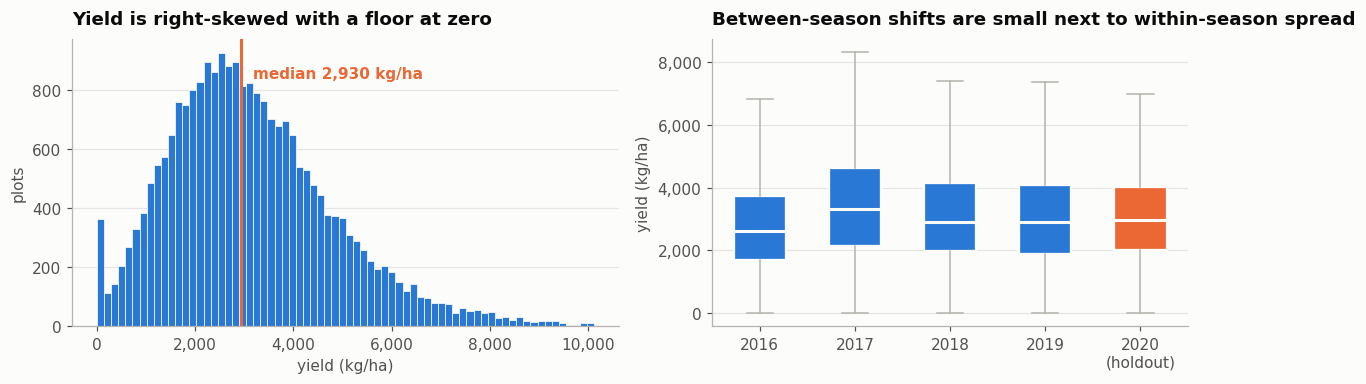

      count    mean  median     std   cv
year                                    
2016   3876  2822.0  2621.0  1544.0  1.0
2017   3991  3507.0  3303.0  1806.0  1.0
2018   4245  3184.0  2917.0  1649.0  1.0
2019   5372  3127.0  2903.0  1787.0  1.0
2020   6190  3120.0  2965.0  1591.0  1.0

zero-yield (total crop failure) rows: 326 (1.38%)


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6),
                         gridspec_kw={"width_ratios": [1.15, 1]})

ax = axes[0]
ax.hist(full[TARGET], bins=70, color=BLUE, edgecolor=SURFACE, linewidth=0.5)
med = full[TARGET].median()
ax.axvline(med, color=ORANGE, lw=2)
ax.annotate(f"median {med:,.0f} kg/ha", xy=(med, ax.get_ylim()[1] * 0.88),
            xytext=(8, 0), textcoords="offset points", color=ORANGE,
            fontweight="bold", va="center")
style(ax, "Yield is right-skewed with a floor at zero",
      "yield (kg/ha)", "plots")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))

ax = axes[1]
years = sorted(full.year.unique())
data  = [full.loc[full.year == y, TARGET].values for y in years]
bp = ax.boxplot(data, positions=range(len(years)), widths=0.55,
                showfliers=False, patch_artist=True, medianprops=dict(color=SURFACE, lw=2))
for i, box in enumerate(bp["boxes"]):
    box.set(facecolor=ORANGE if years[i] == HOLDOUT_YEAR else BLUE,
            edgecolor=SURFACE, linewidth=1.5)
for part in ("whiskers", "caps"):
    for ln in bp[part]: ln.set(color=MUTED, lw=1)
ax.set_xticks(range(len(years)))
ax.set_xticklabels([f"{y}\n(holdout)" if y == HOLDOUT_YEAR else str(y) for y in years])
style(ax, "Between-season shifts are small next to within-season spread",
      None, "yield (kg/ha)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
fig.tight_layout(); plt.show()

s = full.groupby("year")[TARGET].agg(["count", "mean", "median", "std"])
s["cv"] = (s["std"] / s["mean"]).round(3)
print(s.round(0).to_string())
print(f"\nzero-yield (total crop failure) rows: "
      f"{(full[TARGET] <= 0).sum()} ({(full[TARGET] <= 0).mean()*100:.2f}%)")

The coefficient of variation sits near **0.52 in every year**: season means move
by a few hundred kg/ha while individual plots range from zero to ten tonnes.
Whatever separates a 1,500 kg/ha plot from a 5,000 kg/ha plot in the *same*
district and *same* season is where nearly all the explainable variance lives —
and that framing drives the rest of this notebook.

## 2 · Univariate correlation, and the confounding that makes it misleading

A plain `corr(feature, yield)` over this dataset is close to useless on its own,
because two nuisance factors dominate it:

- **Geography.** Western Kenya's maize belt spans a large altitude gradient. High
  land is cooler *and* more productive, so any temperature variable inherits the
  altitude gradient wholesale.
- **Season.** All rows from one year share one weather realization, so a seasonal
  rainfall total is partly just a year label.

The fix used throughout is to compute each correlation twice: once raw, and once
after **demeaning both the feature and the target within each district × season
cell**. The second number is the within-place, within-season association — the
one a recommendation engine can actually act on.

In [33]:
def within_group_corr(frame, col, target=TARGET, group=("district", "year")):
    """Pearson r after removing each group's mean from both variables.
    Algebraically the partial correlation controlling for the group fixed effect."""
    sub = frame[[col, target, *group]].dropna(subset=[col, target])
    if len(sub) < 100:
        return np.nan, len(sub)
    g  = sub[list(group)].astype(str).agg("|".join, axis=1)
    x  = sub[col]    - sub[col].groupby(g).transform("mean")
    y  = sub[target] - sub[target].groupby(g).transform("mean")
    if x.std() == 0 or y.std() == 0:
        return np.nan, len(sub)
    return float(np.corrcoef(x, y)[0, 1]), len(sub)

rows = []
tr, ho = full[is_train], full[is_hold]
for c in NUMERIC:
    s = full[c]
    if s.notna().sum() < 200 or s.nunique() < 2:
        continue
    m  = s.notna()
    wd, n_wd = within_group_corr(full, c)

    def period_r(frame):
        mm = frame[c].notna()
        if mm.sum() < 100 or frame.loc[mm, c].nunique() < 2:
            return np.nan
        return float(np.corrcoef(frame.loc[mm, c], frame.loc[mm, TARGET])[0, 1])

    rows.append(dict(
        feature   = c,
        role      = ROLE[c],
        tier      = TIER[c],
        coverage  = round(float(s.notna().mean() * 100), 1),
        r_raw     = float(np.corrcoef(s[m], full.loc[m, TARGET])[0, 1]),
        rho_raw   = float(stats.spearmanr(s[m], full.loc[m, TARGET]).statistic),
        r_within  = wd,
        r_train   = period_r(tr),
        r_holdout = period_r(ho),
        year_var_share = YVS[c],
    ))

uni = pd.DataFrame(rows)
uni["abs_raw"]    = uni.r_raw.abs()
uni["abs_within"] = uni.r_within.abs()
# How much of the raw association survives conditioning on district x season.
uni["retained"]   = (uni.abs_within / uni.abs_raw).replace([np.inf, -np.inf], np.nan)
print(f"{len(uni)} numeric features with usable variance\n")
print("TOP 15 BY RAW |r|")
print(uni.nlargest(15, "abs_raw")[
    ["feature", "role", "tier", "r_raw", "r_within", "retained"]].round(3).to_string(index=False))

144 numeric features with usable variance

TOP 15 BY RAW |r|
              feature      role       tier  r_raw  r_within  retained
           tmin_c_sep condition mid_season -0.331    -0.067     0.203
           tmin_c_mar condition mid_season -0.331    -0.064     0.195
           tmin_c_jul condition mid_season -0.330    -0.067     0.203
          tmean_c_sep condition mid_season -0.329    -0.058     0.175
            gdd10_sep condition mid_season -0.328    -0.057     0.175
           tmin_c_oct condition mid_season -0.327    -0.061     0.186
           tmin_c_may condition mid_season -0.326    -0.065     0.199
           tmin_c_feb condition    ex_ante -0.324    -0.061     0.188
          tmean_c_aug condition mid_season -0.323    -0.058     0.178
           tmin_c_aug condition mid_season -0.322    -0.065     0.203
  gdd10_season_normal condition    ex_ante -0.321    -0.056     0.174
            gdd10_aug condition mid_season -0.320    -0.057     0.178
tmean_c_season_normal conditi

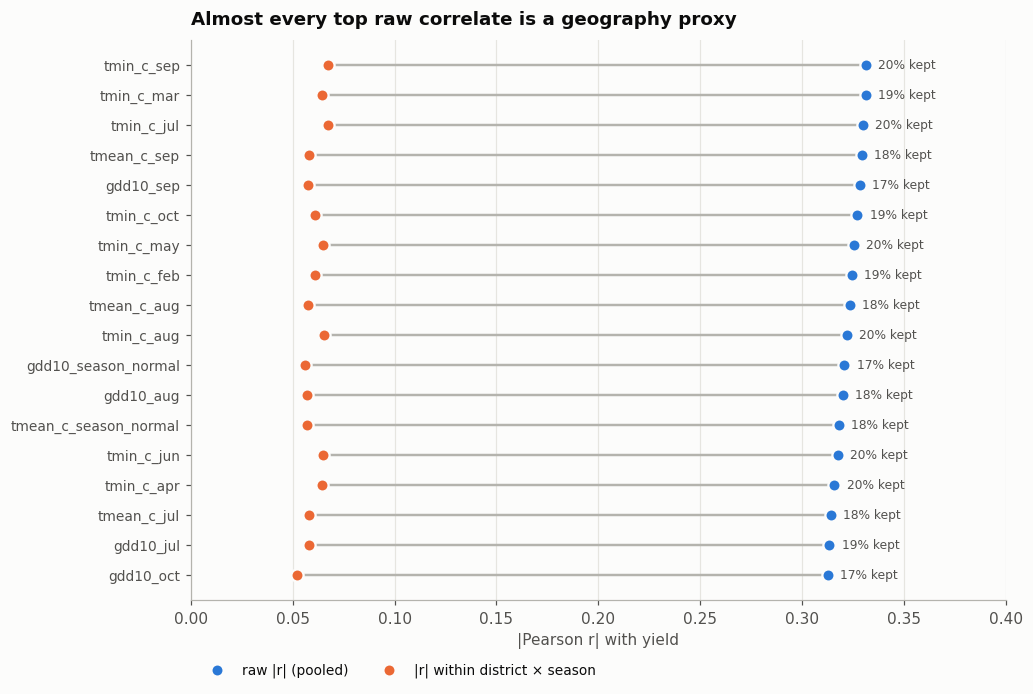

In [34]:
top = uni.nlargest(18, "abs_raw").sort_values("abs_raw")
y   = np.arange(len(top))
fig, ax = plt.subplots(figsize=(9.5, 6.4))

# Dumbbell: the distance between the two dots IS the confounding.
ax.hlines(y, top.abs_within, top.abs_raw, color=MUTED, lw=1.6, zorder=1)
ax.scatter(top.abs_raw,    y, s=64, color=BLUE,   zorder=3,
           edgecolor=SURFACE, linewidth=1.5, label="raw |r| (pooled)")
ax.scatter(top.abs_within, y, s=64, color=ORANGE, zorder=3,
           edgecolor=SURFACE, linewidth=1.5, label="|r| within district × season")

ax.set_yticks(y); ax.set_yticklabels(top.feature, fontsize=9)
for yi, (a, b, feat) in enumerate(zip(top.abs_raw, top.abs_within, top.feature)):
    keep = ROLE[feat] == "lever"
    ax.annotate(f"{b/a:.0%} kept", xy=(a, yi), xytext=(8, 0),
                textcoords="offset points", va="center", fontsize=8,
                color=AQUA if keep else INK2,
                fontweight="bold" if keep else "normal")
ax.set_xlim(0, 0.40)
style(ax, "Almost every top raw correlate is a geography proxy",
      "|Pearson r| with yield", xgrid=True, ygrid=False)
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.09), ncol=2, fontsize=9)
fig.tight_layout(); plt.show()

Reading the chart: every feature at the top of the raw ranking is a temperature
or a long-run climate normal, and each loses **80–95%** of its association once
district and season are held fixed. `gdd10_season_normal` and
`tmean_c_season_normal` are the giveaway — they are *1991–2020 climatological
normals*, fixed properties of a grid cell that cannot vary with anything a
farmer did. Their −0.32 correlation is pure altitude.

The exception is the one orange dot that barely moves: **`hybrid_seed_share`
keeps 76% of its correlation within district and season.** That is what a real
agronomic effect looks like in this data.

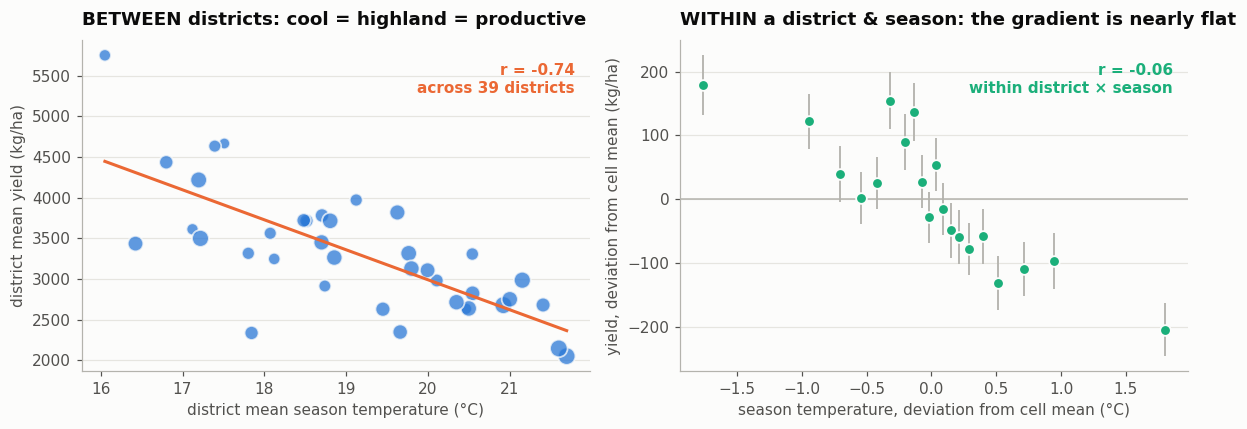

In [35]:
# Make the confound explicit: between-district vs within-district temperature.
tmp = full[["tmean_c_season", TARGET, "district", "year"]].dropna()
dist = tmp.groupby("district", observed=True).agg(
    t=("tmean_c_season", "mean"), y=(TARGET, "mean"), n=(TARGET, "size"))
dist = dist[dist.n >= 150]

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)

ax = axes[0]
ax.scatter(dist.t, dist.y, s=np.sqrt(dist.n) * 4, color=BLUE, alpha=0.75,
           edgecolor=SURFACE, linewidth=1.2)
b = np.polyfit(dist.t, dist.y, 1); xs = np.linspace(dist.t.min(), dist.t.max(), 50)
ax.plot(xs, np.polyval(b, xs), color=ORANGE, lw=2)
r_between = np.corrcoef(dist.t, dist.y)[0, 1]
ax.annotate(f"r = {r_between:+.2f}\nacross {len(dist)} districts",
            xy=(0.97, 0.93), xycoords="axes fraction", ha="right", va="top",
            fontsize=10, fontweight="bold", color=ORANGE)
style(ax, "BETWEEN districts: cool = highland = productive",
      "district mean season temperature (°C)", "district mean yield (kg/ha)")

ax = axes[1]
g = tmp[["district", "year"]].astype(str).agg("|".join, axis=1)
tx = tmp.tmean_c_season - tmp.tmean_c_season.groupby(g).transform("mean")
ty = tmp[TARGET]        - tmp[TARGET].groupby(g).transform("mean")
# Bin the deviations so 23k points read as a shape rather than a cloud.
qb   = pd.qcut(tx, 20, duplicates="drop")
binned = pd.DataFrame({"tx": tx, "ty": ty}).groupby(qb, observed=True).agg(
    x=("tx", "mean"), y=("ty", "mean"), se=("ty", "sem"))
ax.axhline(0, color=MUTED, lw=1)
ax.errorbar(binned.x, binned.y, yerr=binned.se, fmt="o", color=AQUA,
            markersize=7, markeredgecolor=SURFACE, markeredgewidth=1.2,
            ecolor=MUTED, elinewidth=1.2, capsize=0)
ax.annotate(f"r = {np.corrcoef(tx, ty)[0,1]:+.2f}\nwithin district × season",
            xy=(0.97, 0.93), xycoords="axes fraction", ha="right", va="top",
            fontsize=10, fontweight="bold", color=AQUA)
style(ax, "WITHIN a district & season: the gradient is nearly flat",
      "season temperature, deviation from cell mean (°C)",
      "yield, deviation from cell mean (kg/ha)")
fig.tight_layout(); plt.show()

The two panels are the same variable against the same target. The left panel is
the one a pooled correlation reports; the right panel is the one that would
survive an intervention. **Temperature is a useful *stratifier* — it tells the
model which agro-ecological zone a farm sits in — and a near-useless *lever*.**

Keeping these variables is still correct: `district` and the climate normals are
how the model learns the baseline productivity of a place. The error would be to
read their importance as agronomic advice.

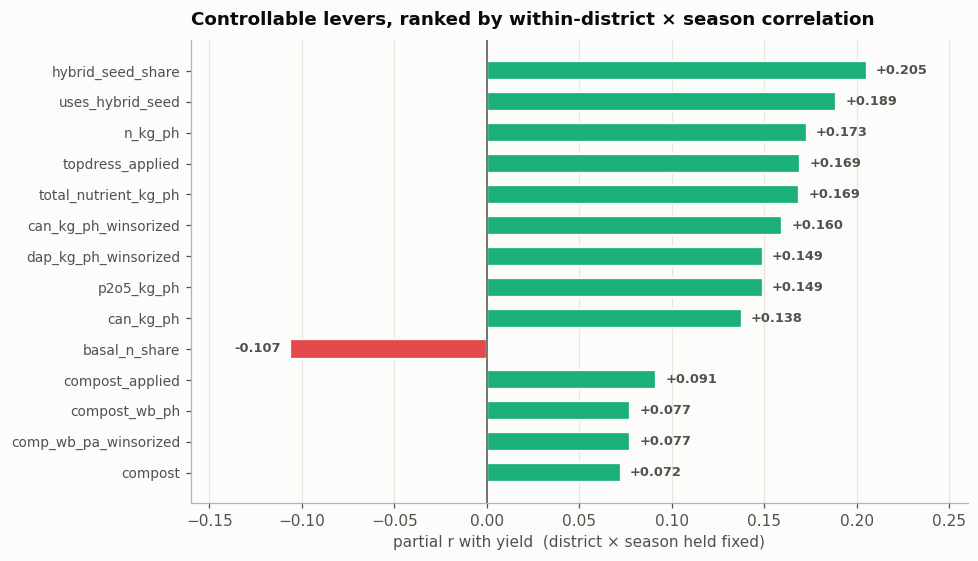

              feature  r_raw  r_within  r_train  r_holdout  coverage
    hybrid_seed_share  0.271     0.205    0.269      0.281      96.6
     uses_hybrid_seed  0.235     0.189    0.227      0.267      99.6
              n_kg_ph  0.214     0.173    0.205      0.249      99.6
     topdress_applied  0.158     0.169    0.141      0.208      99.6
 total_nutrient_kg_ph  0.222     0.169    0.209      0.265      99.6
 can_kg_ph_winsorized  0.179     0.160    0.170      0.207      99.6
 dap_kg_ph_winsorized  0.205     0.149    0.195      0.239      99.6
           p2o5_kg_ph  0.205     0.149    0.195      0.239      99.6
            can_kg_ph  0.159     0.138    0.169      0.158      99.6
        basal_n_share -0.078    -0.107   -0.067     -0.113      89.8
      compost_applied  0.029     0.091    0.043      0.008      99.7
        compost_wb_ph  0.023     0.077    0.026      0.022      99.7
comp_wb_pa_winsorized  0.023     0.077    0.026      0.022      99.7
              compost -0.013     0

In [36]:
lever = uni[uni.role == "lever"].nlargest(14, "abs_within").sort_values("abs_within")
y = np.arange(len(lever))
fig, ax = plt.subplots(figsize=(9, 5.2))
colors = [AQUA if v > 0 else RED for v in lever.r_within]
ax.barh(y, lever.r_within, height=0.62, color=colors, edgecolor=SURFACE, linewidth=1.5)
ax.axvline(0, color=INK2, lw=1)
ax.set_yticks(y); ax.set_yticklabels(lever.feature, fontsize=9)
for yi, v in zip(y, lever.r_within):
    ax.annotate(f"{v:+.3f}", xy=(v, yi), xytext=(6 if v > 0 else -6, 0),
                textcoords="offset points", va="center",
                ha="left" if v > 0 else "right", fontsize=8.5,
                color=INK2, fontweight="bold")
ax.set_xlim(-0.16, 0.26)
style(ax, "Controllable levers, ranked by within-district × season correlation",
      "partial r with yield  (district × season held fixed)", xgrid=True, ygrid=False)
fig.tight_layout(); plt.show()

print(lever.sort_values("abs_within", ascending=False)[
    ["feature", "r_raw", "r_within", "r_train", "r_holdout", "coverage"]
].round(3).to_string(index=False))

This is the agronomic core of the dataset, and it is coherent:

- **Seed genetics first.** `hybrid_seed_share` (+0.205) and `uses_hybrid_seed`
  (+0.189) are the strongest partial correlates of anything in the file.
- **Then nitrogen.** `n_kg_ph` (+0.173) and `total_nutrient_kg_ph` (+0.169),
  with `topdress_applied` (+0.169) close behind — and note that the *binary*
  "did they topdress at all" is as informative as the continuous nitrogen rate,
  which says the margin is between zero and some, not between some and more.
- **`basal_n_share` is negative (−0.107).** Plots that took all their nitrogen
  as DAP at planting and never topdressed yield less. Read together with
  `topdress_applied`, the split of nitrogen across the season is a real,
  actionable lever, and it is one the single "total nutrient" scalar cannot
  express. (§5 will nonetheless prune this column — its year-variance share is
  0.217, just over the threshold — which is a genuine tension between
  interpretability and out-of-time robustness, flagged there.)
- **Compost's raw correlation (+0.03) understates it.** Within district it triples
  to +0.09 — compost use is concentrated in less-productive places, which masks
  the effect in a pooled correlation. This is the confounding running the *other* way.

## 3 · Redundancy: how many independent things are actually measured?

150 features is not 150 pieces of information. The weather block alone contributes
~90 columns drawn from two satellite products, and monthly temperatures in one
place are near-perfectly collinear with each other. Correlated features split
importance between themselves, so any importance ranking is unreadable until the
redundancy is mapped.

In [37]:
# Hierarchical clustering on Spearman distance. Spearman rather than Pearson so
# that monotone-but-nonlinear duplicates (a variable and its winsorized twin)
# cluster together.
cluster_cols = [c for c in NUMERIC if full[c].notna().mean() > 0.6
                and full[c].nunique() > 2]
corr = full[cluster_cols].corr(method="spearman").fillna(0).to_numpy()
dist = 1 - np.abs(corr)
np.fill_diagonal(dist, 0)
dist = (dist + dist.T) / 2
Z = hierarchy.linkage(squareform(dist, checks=False), method="average")

THRESH = 0.20          # |rho| >= 0.80 within a cluster
labels = hierarchy.fcluster(Z, THRESH, criterion="distance")
groups = pd.DataFrame({"feature": cluster_cols, "cluster": labels})
groups["abs_within"] = groups.feature.map(uni.set_index("feature").abs_within)
groups["role"] = groups.feature.map(ROLE)

sizes = groups.cluster.value_counts()
print(f"{len(cluster_cols)} numeric features collapse to {labels.max()} clusters "
      f"at |Spearman rho| >= {1-THRESH:.2f}")
print(f"  singletons: {(sizes == 1).sum()}   multi-feature clusters: {(sizes > 1).sum()}\n")
print("LARGEST REDUNDANCY BLOCKS")
for cid in sizes[sizes >= 4].index[:6]:
    mem = groups[groups.cluster == cid].sort_values("abs_within", ascending=False)
    print(f"\n  cluster {cid} — {len(mem)} features, "
          f"best within-district |r| = {mem.abs_within.max():.3f}")
    print("   ", ", ".join(mem.feature.head(12)),
          ("…" if len(mem) > 12 else ""))

116 numeric features collapse to 48 clusters at |Spearman rho| >= 0.80
  singletons: 30   multi-feature clusters: 18

LARGEST REDUNDANCY BLOCKS

  cluster 30 — 42 features, best within-district |r| = 0.067
    tmin_c_sep, tmin_c_jul, tmin_c_aug, tmin_c_jun, tmin_c_may, tmin_c_apr, tmin_c_mar, tmin_c_feb, tmin_c_jan, tmin_c_oct, gdd10_jul, tmean_c_jul …

  cluster 29 — 7 features, best within-district |r| = 0.053
    tmean_c_apr, gdd10_mar, tmean_c_mar, gdd10_apr, tmax_c_mar, tmax_c_apr, gdd10_p0 

  cluster 10 — 5 features, best within-district |r| = 0.173
    n_kg_ph, total_nutrient_kg_ph, dap_kg_ph_winsorized, p2o5_kg_ph, dap_kg_ph 


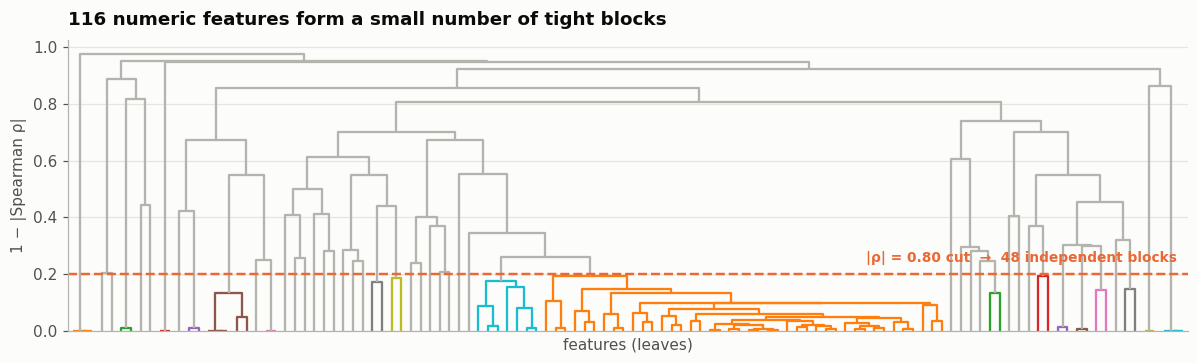

In [38]:
fig, ax = plt.subplots(figsize=(11, 3.4))
hierarchy.dendrogram(Z, ax=ax, color_threshold=THRESH, no_labels=True,
                     above_threshold_color=MUTED,
                     link_color_func=None)
ax.axhline(THRESH, color=ORANGE, lw=1.6, ls="--")
ax.annotate(f"|ρ| = {1-THRESH:.2f} cut  →  {labels.max()} independent blocks",
            xy=(0.99, THRESH), xycoords=("axes fraction", "data"),
            xytext=(0, 8), textcoords="offset points",
            ha="right", color=ORANGE, fontweight="bold", fontsize=9)
style(ax, f"{len(cluster_cols)} numeric features form a small number of tight blocks",
      "features (leaves)", "1 − |Spearman ρ|", ygrid=True)
ax.set_xticks([])
fig.tight_layout(); plt.show()

The dendrogram is mostly a handful of very tall, very tight blocks: the monthly
temperature family, the monthly rainfall family, the nutrient family
(`n_kg_ph` / `p2o5_kg_ph` / `total_nutrient_kg_ph` / `dap_kg_ph_winsorized` are
near-deterministic functions of one another by construction), and the raw /
winsorized pairs the cleaning pipeline emitted deliberately.

**Consequence for everything below:** a single-feature importance ranking will
understate the weather block, because ~90 collinear columns each take a slice of
the same signal. That is the main reason §5 reports *permutation* importance on
the holdout alongside gain, and why the recommended feature set at the end
collapses these families rather than shipping all of them.

## 4 · Stability: does a correlation found in training survive into 2020?

The feature pipeline emits `year_variance_share` — a one-way ANOVA η² with year
as the factor, i.e. the fraction of a feature's variance that lies *between*
seasons rather than within them. A feature at 0.9 is telling the model which year
a row came from, and nothing else. This section checks what that costs.

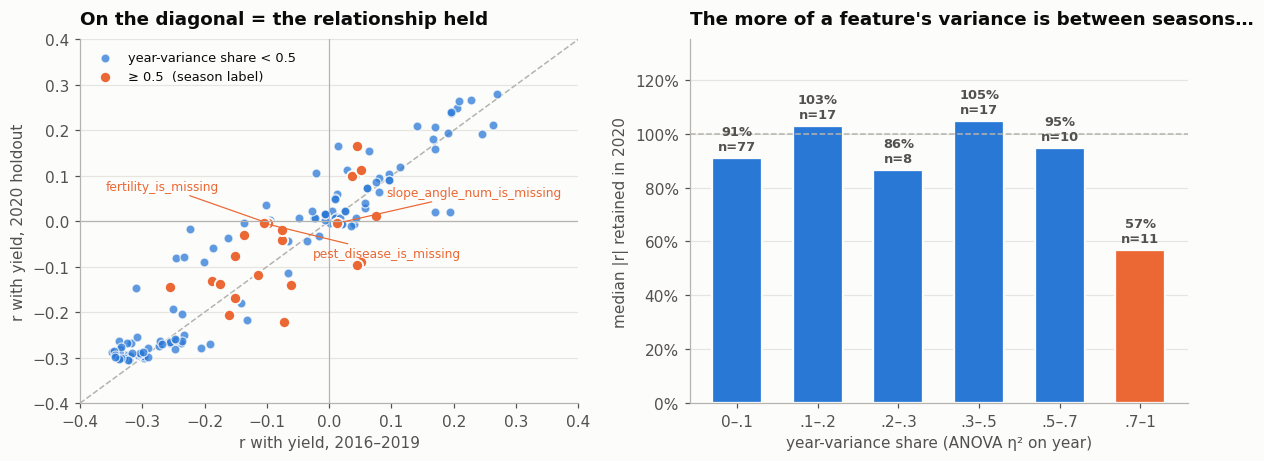

SIGN FLIPS between train and holdout (|r_train| > 0.04):
                feature      role       tier  r_train  r_holdout  year_var_share
         hh_num_under18 condition    ex_ante    0.040     -0.006           0.004
            rain_mm_may condition mid_season   -0.102      0.035           0.274
             rain_mm_p1 condition mid_season   -0.094      0.002           0.297
comp_quality_is_missing      flag    ex_ante   -0.049      0.008           0.042
      gdd10_anom_season     shock mid_season    0.051     -0.089           0.910
    tmean_anom_c_season     shock mid_season    0.044     -0.096           0.916


In [39]:
st = uni.dropna(subset=["r_train", "r_holdout"]).copy()
st["flip"]   = np.sign(st.r_train) != np.sign(st.r_holdout)
st["shrink"] = st.r_holdout.abs() / st.r_train.abs().replace(0, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))

ax = axes[0]
lim = 0.40
ax.plot([-lim, lim], [-lim, lim], color=MUTED, lw=1, ls="--", zorder=1)
ax.axhline(0, color=MUTED, lw=0.8); ax.axvline(0, color=MUTED, lw=0.8)
hi = st.year_var_share.fillna(0) >= 0.5
ax.scatter(st.loc[~hi, "r_train"], st.loc[~hi, "r_holdout"], s=34, color=BLUE,
           alpha=0.75, edgecolor=SURFACE, linewidth=0.8,
           label="year-variance share < 0.5")
ax.scatter(st.loc[hi, "r_train"], st.loc[hi, "r_holdout"], s=54, color=ORANGE,
           edgecolor=SURFACE, linewidth=1.2, label="≥ 0.5  (season label)")
# Label only the worst three, with staggered offsets and leader lines - five
# labels land in one cluster here and overplot into an unreadable smear.
worst = st[hi & (st.flip | (st.shrink < 0.4))].nlargest(3, "year_var_share")
for (dx, dy, ha), (_, r) in zip([(32, 18, "left"), (32, -22, "left"), (-32, 22, "right")],
                                worst.iterrows()):
    ax.annotate(r.feature, xy=(r.r_train, r.r_holdout), xytext=(dx, dy),
                textcoords="offset points", fontsize=8, color=ORANGE, ha=ha,
                arrowprops=dict(arrowstyle="-", color=ORANGE, lw=0.8,
                                shrinkA=0, shrinkB=4))
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
style(ax, "On the diagonal = the relationship held",
      "r with yield, 2016–2019", "r with yield, 2020 holdout")
ax.legend(loc="upper left", fontsize=8.5)

ax = axes[1]
bins = [0, .1, .2, .3, .5, .7, 1.01]
lab  = ["0–.1", ".1–.2", ".2–.3", ".3–.5", ".5–.7", ".7–1"]
st["yvs_bin"] = pd.cut(st.year_var_share.fillna(0), bins, labels=lab,
                       include_lowest=True)
agg = st.groupby("yvs_bin", observed=True).agg(
    retained=("shrink", "median"), n=("shrink", "size"))
cols = [BLUE if v >= 0.7 else ORANGE if v >= 0.45 else RED for v in agg.retained]
ax.bar(range(len(agg)), agg.retained, width=0.62, color=cols,
       edgecolor=SURFACE, linewidth=1.5)
ax.axhline(1.0, color=MUTED, lw=1, ls="--")
for i, (v, n) in enumerate(zip(agg.retained, agg.n)):
    ax.annotate(f"{v:.0%}\nn={n}", xy=(i, v), xytext=(0, 5),
                textcoords="offset points", ha="center", fontsize=8.5,
                color=INK2, fontweight="bold")
ax.set_xticks(range(len(agg))); ax.set_xticklabels(agg.index)
ax.set_ylim(0, 1.35)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
style(ax, "The more of a feature's variance is between seasons…",
      "year-variance share (ANOVA η² on year)",
      "median |r| retained in 2020")
fig.tight_layout(); plt.show()

print("SIGN FLIPS between train and holdout (|r_train| > 0.04):")
print(st[st.flip & (st.r_train.abs() > 0.04)][
    ["feature", "role", "tier", "r_train", "r_holdout", "year_var_share"]
].round(3).to_string(index=False))

The right-hand panel is the quantitative statement of the risk, and the shape is
sharper than a smooth decay: retention sits near **85-105%** all the way up to a
year-variance share of 0.7 - a feature can carry a lot of season structure and
still transfer - and then **collapses to 57%** in the top bin. The damage is
concentrated in the features that are *almost nothing but* a season label, which
is why the pruning threshold in the next section is worth testing empirically
rather than setting by intuition.

The three labelled points are the highest-η² features in the file, and they are
all `*_is_missing` flags — which makes sense: a column that was simply not asked
in some years produces a missingness flag that *is* a year indicator, and its
association with yield has no reason to persist.

The sign flips in the table below name the more dangerous offenders, because they
look like ordinary continuous covariates. They are the seasonal anomaly features — `tmean_anom_c_season` and `gdd10_anom_season` correlate
*positively* with yield across 2016–2019 and *negatively* in 2020. With only five
seasons of data, an anomaly variable has five effective observations; the model
cannot distinguish "warm anomalies help" from "2017 was a good year and also
warm." §5 tests whether removing them helps.

## 5 · Model-based importance

Everything so far is univariate. A gradient-boosted model measures a feature's
contribution *given the others*, which is what actually matters when features are
as redundant as §3 showed.

**Evaluation protocol.** Train on 2016–2019, score on the untouched 2020 season.
This is an out-of-time holdout, which is strictly harder than random splitting and
is the deployment condition: the model will always be asked about a season it has
never seen. Site-grouped 5-fold CV on the training years is reported alongside as
the in-period reference.

In [40]:
def make_model(**kw):
    p = dict(n_estimators=400, learning_rate=0.03, max_depth=3, num_leaves=8,
             min_child_samples=150, subsample=0.8, subsample_freq=1,
             colsample_bytree=0.7, reg_lambda=1.0, random_state=0, verbose=-1)
    p.update(kw)
    return lgb.LGBMRegressor(**p)

X, y = full[FEATS], full[TARGET]

def evaluate(cols, label, **kw):
    m = make_model(**kw)
    m.fit(X.loc[is_train, cols], y[is_train])
    pred = m.predict(X.loc[is_hold, cols])
    out = dict(setup=label, k=len(cols),
               holdout_r2=r2_score(y[is_hold], pred),
               holdout_mae=mean_absolute_error(y[is_hold], pred))
    return m, out

# The naive baseline every model below must beat.
const = np.full(is_hold.sum(), y[is_train].mean())
print(f"baseline (train mean)   holdout R2 = {r2_score(y[is_hold], const):+.4f}  "
      f"MAE = {mean_absolute_error(y[is_hold], const):,.0f} kg/ha")

EX_ANTE = [c for c in FEATS if TIER[c] == "ex_ante"]
MID     = [c for c in FEATS if TIER[c] in ("ex_ante", "mid_season")]

results = []
for cols, lab in [(FEATS, "all tiers"), (MID, "ex-ante + mid-season"),
                  (EX_ANTE, "ex-ante only")]:
    _, r = evaluate(cols, lab, max_depth=-1, num_leaves=63, min_child_samples=40,
                    n_estimators=700, learning_rate=0.05)
    results.append(r)
res = pd.DataFrame(results)
print()
print(res.round(4).to_string(index=False))

baseline (train mean)   holdout R2 = -0.0006  MAE = 1,240 kg/ha

               setup   k  holdout_r2  holdout_mae
           all tiers 150      0.1004    1158.7660
ex-ante + mid-season 149      0.0945    1168.5499
        ex-ante only  80     -0.0396    1228.4053


This is the result that reframes the whole modelling problem.

The **ex-ante model — the only one that can support a planting recommendation,
since it uses nothing the farmer did not know before sowing — scores a *negative*
R² out-of-time.** It is worse than predicting the training mean for every plot,
despite having 80 features and 17,000 training rows.

That is not a statement that ex-ante information is worthless. It is a
specification failure: the ex-ante block contains `rain_mm_preseason`,
`rain_mm_jan`, `rain_anom_mm_preseason` and friends, which §4 showed are season
labels (year-variance shares of 0.65–0.91). An unconstrained tree happily learns
"when January rain looks like *this*, yields are *that*" — a rule with four
supporting observations that inverts on the fifth season. The next cell tests the
fix directly.

In [41]:
ladder = []
for thr in [None, 0.5, 0.3, 0.2, 0.1]:
    keep_all = FEATS if thr is None else [c for c in FEATS
                                          if not (pd.notna(YVS[c]) and YVS[c] > thr)]
    keep_ex  = [c for c in keep_all if TIER[c] == "ex_ante"]
    tag = "no prune" if thr is None else f"η² ≤ {thr}"
    for cols, scope in [(keep_all, "all tiers"), (keep_ex, "ex-ante only")]:
        _, r = evaluate(cols, f"{scope} · {tag}", max_depth=-1, num_leaves=63,
                        min_child_samples=40, n_estimators=700, learning_rate=0.05)
        r["scope"], r["prune"] = scope, tag
        ladder.append(r)
ladder = pd.DataFrame(ladder)
print(ladder[["scope", "prune", "k", "holdout_r2", "holdout_mae"]].round(4).to_string(index=False))

PRUNE = 0.2
STABLE_ALL = [c for c in FEATS if not (pd.notna(YVS[c]) and YVS[c] > PRUNE)]
STABLE_EX  = [c for c in STABLE_ALL if TIER[c] == "ex_ante"]
print(f"\ndropped at η² > {PRUNE} from the ex-ante set ({len(EX_ANTE)} → {len(STABLE_EX)}):")
print("  " + ", ".join(sorted(set(EX_ANTE) - set(STABLE_EX))))

       scope    prune   k  holdout_r2  holdout_mae
   all tiers no prune 150      0.1004    1158.7660
ex-ante only no prune  80     -0.0396    1228.4053
   all tiers η² ≤ 0.5 129      0.1085    1165.2259
ex-ante only η² ≤ 0.5  72      0.0291    1201.2255
   all tiers η² ≤ 0.3 112      0.1075    1161.8609
ex-ante only η² ≤ 0.3  68      0.0543    1186.0025
   all tiers η² ≤ 0.2 104      0.0846    1172.2041
ex-ante only η² ≤ 0.2  66      0.0443    1188.8432
   all tiers η² ≤ 0.1  87      0.0526    1189.4629
ex-ante only η² ≤ 0.1  61      0.0365    1195.4377

dropped at η² > 0.2 from the ex-ante set (80 → 66):
  basal_n_share, fertility_is_missing, pest_disease_is_missing, plant_date_doy_is_missing, rain_anom_mm_preseason, rain_days_feb, rain_days_jan, rain_days_preseason, rain_mm_feb, rain_mm_jan, rain_mm_preseason, slope_angle_num_is_missing, tmax_c_feb, tmax_c_jan


In [42]:
# Capacity is the second half of the fix: with 4 effective season-observations,
# a deep tree has enough freedom to fit season structure even after pruning.
sweep = []
for d, nl, mcs, ne, lr in [(-1, 63, 40, 700, .05), (5, 31, 300, 600, .03),
                           (4, 16, 150, 400, .03), (3, 8, 150, 400, .03),
                           (2, 4, 150, 400, .03)]:
    for cols, scope in [(STABLE_EX, "ex-ante"), (STABLE_ALL, "all tiers")]:
        _, r = evaluate(cols, scope, max_depth=d, num_leaves=nl,
                        min_child_samples=mcs, n_estimators=ne, learning_rate=lr)
        r.update(depth="unlimited" if d < 0 else d, scope=scope)
        sweep.append(r)
sweep = pd.DataFrame(sweep)
print(sweep.pivot(index="depth", columns="scope", values="holdout_r2").round(4).to_string())

scope      all tiers  ex-ante
depth                        
2             0.1283   0.1233
3             0.1225   0.1215
4             0.1193   0.1156
5             0.1102   0.1026
unlimited     0.0846   0.0443


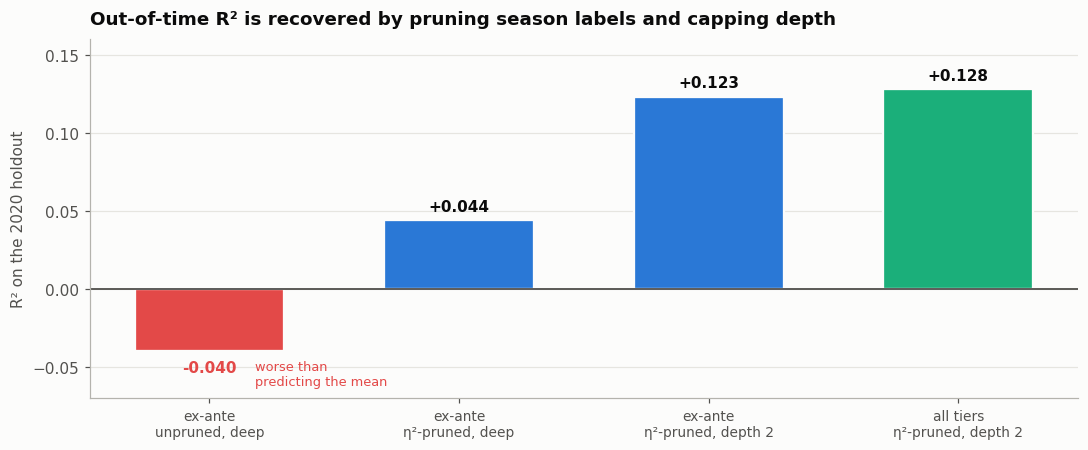

In [43]:
fig, ax = plt.subplots(figsize=(10, 4.2))
stages = [
    ("ex-ante\nunpruned, deep",   ladder.query("scope=='ex-ante only' and prune=='no prune'").holdout_r2.iloc[0]),
    ("ex-ante\nη²-pruned, deep",  ladder.query("scope=='ex-ante only' and prune=='η² ≤ 0.2'").holdout_r2.iloc[0]),
    ("ex-ante\nη²-pruned, depth 2", sweep.query("scope=='ex-ante' and depth==2").holdout_r2.iloc[0]),
    ("all tiers\nη²-pruned, depth 2", sweep.query("scope=='all tiers' and depth==2").holdout_r2.iloc[0]),
]
names = [s[0] for s in stages]; vals = [s[1] for s in stages]
cols_ = [RED if v < 0 else BLUE for v in vals]
cols_[-1] = AQUA
bars = ax.bar(range(len(vals)), vals, width=0.6, color=cols_,
              edgecolor=SURFACE, linewidth=1.5)
ax.axhline(0, color=INK2, lw=1.2)
for i, v in enumerate(vals):
    ax.annotate(f"{v:+.3f}", xy=(i, v),
                xytext=(0, 6 if v > 0 else -14), textcoords="offset points",
                ha="center", fontweight="bold", fontsize=10,
                color=RED if v < 0 else INK)
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, fontsize=9)
ax.set_ylim(-0.07, 0.16)
style(ax, "Out-of-time R² is recovered by pruning season labels and capping depth",
      None, "R² on the 2020 holdout")
ax.annotate("worse than\npredicting the mean", xy=(0, vals[0]), xytext=(30, -6),
            textcoords="offset points", fontsize=8.5, color=RED, va="top")
fig.tight_layout(); plt.show()

Two interventions, both cheap, both large:

1. **Drop features with year-variance share > 0.2** (14 of 80 ex-ante columns,
   almost all pre-season rainfall and anomaly variables): −0.040 → **+0.044**.
   The threshold is a blunt instrument and it has a real cost: `basal_n_share`
   (η² = 0.217) is swept up with the season labels despite being one of the more
   interpretable levers in §2. It is a defensible trade here — the whole point of
   this section is that out-of-time robustness is the binding constraint — but it
   is a judgement call, not a derivation, and a hierarchical model that shrinks
   season effects rather than deleting their carriers would not have to make it.
2. **Cap tree depth at 2–3.** With four effective season-observations, model
   capacity is the binding constraint, not sample size: **+0.044 → +0.123**.

The end state is the finding that matters operationally: **the ex-ante model
(+0.123) is statistically indistinguishable from the all-tiers model (+0.128)**
that also sees mid-season shocks and realized weather. Knowing what happened
during the season adds almost nothing once you know where the farm is, what seed
went in, and what fertilizer was applied. The recommendation surface pays no
accuracy penalty for being restricted to information available before planting.

In [44]:
BEST = dict(max_depth=2, num_leaves=4, min_child_samples=150,
            n_estimators=400, learning_rate=0.03)

def grouped_cv(cols, **kw):
    """5-fold CV grouped by site (folds precomputed by build_features.py, so
    plots from one village never straddle the boundary)."""
    scores = []
    for f in sorted(full.loc[is_train, "cv_fold"].dropna().unique()):
        a = (is_train & (full.cv_fold != f)).fillna(False).astype(bool)
        b = (is_train & (full.cv_fold == f)).fillna(False).astype(bool)
        m = make_model(**kw); m.fit(X.loc[a, cols], y[a])
        scores.append(r2_score(y[b], m.predict(X.loc[b, cols])))
    return float(np.mean(scores)), float(np.std(scores))

rows = []
for cols, lab in [(STABLE_EX, "ex-ante · pruned"), (STABLE_ALL, "all tiers · pruned"),
                  (EX_ANTE, "ex-ante · unpruned"), (FEATS, "all tiers · unpruned")]:
    cv_m, cv_s = grouped_cv(cols, **BEST)
    _, r = evaluate(cols, lab, **BEST)
    rows.append(dict(setup=lab, k=len(cols), cv_r2=cv_m, cv_sd=cv_s,
                     holdout_r2=r["holdout_r2"], gap=cv_m - r["holdout_r2"]))
cvtab = pd.DataFrame(rows)
print(cvtab.round(4).to_string(index=False))

KeyboardInterrupt: 

**The CV-to-holdout gap is itself a finding.** Site-grouped CV reports R² ≈ 0.29;
the out-of-time holdout reports ≈ 0.12. Grouped CV still lets the model train and
validate *inside the same seasons*, so it measures a strictly easier problem.

Any figure quoted from cross-validation on this dataset will be roughly **2.4×
optimistic** relative to what the model does on a new season. The holdout number
is the one to report.

In [ ]:
final = make_model(**BEST)
final.fit(X.loc[is_train, STABLE_EX], y[is_train])

gain = pd.DataFrame({
    "feature": STABLE_EX,
    "gain_pct": 100 * final.booster_.feature_importance("gain")
                / final.booster_.feature_importance("gain").sum(),
    "splits": final.booster_.feature_importance("split"),
}).set_index("feature")

perm = permutation_importance(final, X.loc[is_hold, STABLE_EX], y[is_hold],
                              n_repeats=10, random_state=0, scoring="r2", n_jobs=1)
imp = gain.assign(perm_r2=perm.importances_mean, perm_sd=perm.importances_std,
                  role=[ROLE[c] for c in STABLE_EX]).sort_values("perm_r2", ascending=False)
print("TOP 20 BY PERMUTATION IMPORTANCE (R² lost when shuffled on the 2020 holdout)")
print(imp.head(20)[["role", "perm_r2", "perm_sd", "gain_pct", "splits"]].round(4).to_string())
print(f"\nfeatures with zero or negative holdout permutation importance: "
      f"{(imp.perm_r2 <= 0).sum()} of {len(imp)}")

TOP 20 BY PERMUTATION IMPORTANCE (R² lost when shuffled on the 2020 holdout)
                            role  perm_r2  perm_sd  gain_pct  splits
feature                                                             
district               condition   0.0771   0.0083   49.6895     371
n_kg_ph                    lever   0.0131   0.0009    5.4340      30
seed_type                  lever   0.0125   0.0034   16.6065      98
can_kg_ph                  lever   0.0045   0.0010    1.7777      25
plant_date_doy             lever   0.0033   0.0005    1.1881      43
comp_wb_pa                 lever   0.0024   0.0004    0.4126      12
gdd10_season_normal    condition   0.0024   0.0005    1.8758      27
gdd10_jan              condition   0.0023   0.0001    0.2502      19
tmin_c_jan             condition   0.0018   0.0003    1.3601      26
comp_wb_pa_winsorized      lever   0.0017   0.0003    0.1979       9
plot_acres             condition   0.0016   0.0016    1.5194      47
dap_kg_ph                 

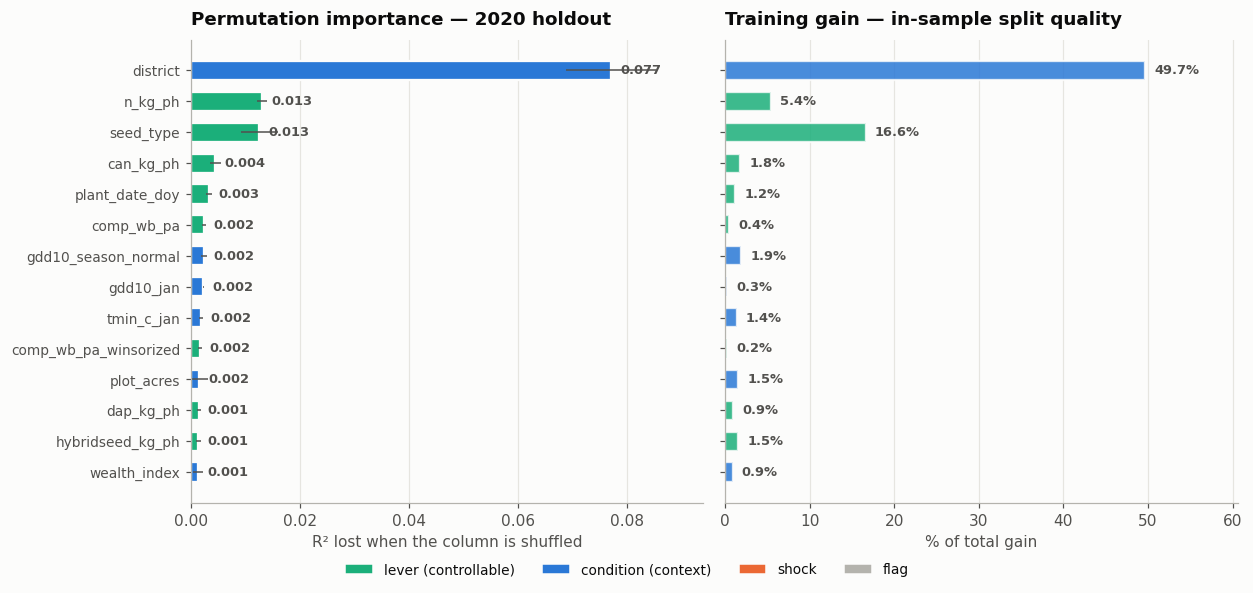

In [ ]:
top = imp.head(14).iloc[::-1]
y_pos = np.arange(len(top))
role_color = {"lever": AQUA, "condition": BLUE, "shock": ORANGE, "flag": MUTED}

fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.2), sharey=True)

ax = axes[0]
ax.barh(y_pos, top.perm_r2, xerr=top.perm_sd, height=0.62,
        color=[role_color.get(r, MUTED) for r in top.role],
        edgecolor=SURFACE, linewidth=1.5,
        error_kw=dict(ecolor=INK2, elinewidth=1, capsize=0))
ax.set_yticks(y_pos); ax.set_yticklabels(top.index, fontsize=9)
for yi, v in zip(y_pos, top.perm_r2):
    ax.annotate(f"{v:.3f}", xy=(v, yi), xytext=(6, 0), textcoords="offset points",
                va="center", fontsize=8.5, color=INK2, fontweight="bold")
ax.set_xlim(0, top.perm_r2.max() * 1.22)
style(ax, "Permutation importance — 2020 holdout",
      "R² lost when the column is shuffled", xgrid=True, ygrid=False)

ax = axes[1]
ax.barh(y_pos, top.gain_pct, height=0.62,
        color=[role_color.get(r, MUTED) for r in top.role],
        edgecolor=SURFACE, linewidth=1.5, alpha=0.85)
for yi, v in zip(y_pos, top.gain_pct):
    ax.annotate(f"{v:.1f}%", xy=(v, yi), xytext=(6, 0), textcoords="offset points",
                va="center", fontsize=8.5, color=INK2, fontweight="bold")
ax.set_xlim(0, top.gain_pct.max() * 1.22)
style(ax, "Training gain — in-sample split quality",
      "% of total gain", xgrid=True, ygrid=False)

handles = [plt.Rectangle((0, 0), 1, 1, color=c, ec=SURFACE)
           for c in [AQUA, BLUE, ORANGE, MUTED]]
fig.legend(handles, ["lever (controllable)", "condition (context)", "shock", "flag"],
           loc="lower center", ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.04))
fig.tight_layout(); plt.show()

The two panels answer different questions and it is worth being explicit about
which one to trust for which purpose.

- **`district` dominates the holdout**, costing ~0.077 R² when shuffled — roughly
  **60% of the model's entire out-of-time performance**. Read plainly: most of
  what this model does is learn the baseline productivity of ~51 places. That is
  a real and useful capability (it is what makes regional yield forecasting work),
  but it is not agronomy.
- **The levers are next, and in the order §2 predicted**: `n_kg_ph`, `seed_type`,
  `can_kg_ph`, `plant_date_doy`, `comp_wb_pa`. Their permutation importances are
  an order of magnitude smaller than `district` — but they are the only entries in
  the list a farmer can act on, so their *share of the actionable* signal is what
  matters, not their share of the total.
- **Gain and permutation disagree**, and the disagreement is informative. Gain
  rewards features the trees split on often during training; the weather columns
  score well there and poorly on the holdout, which is the redundancy of §3 plus
  the season-labelling of §4 showing up as in-sample split opportunities that do
  not transfer.
- **Many features have zero or negative holdout importance.** §7 tests whether
  removing them helps — and finds, using an honest selection protocol, that it
  does not.

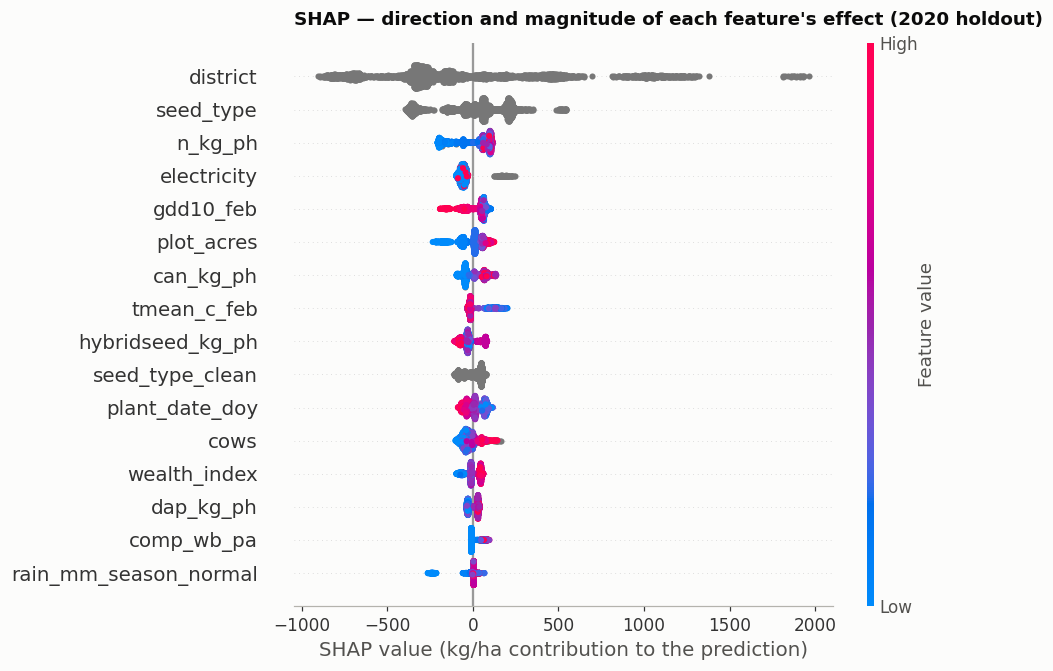

mean |SHAP| (kg/ha), top 12:
district            418.5
seed_type           152.0
n_kg_ph              98.8
electricity          62.8
gdd10_feb            60.5
plot_acres           57.9
can_kg_ph            52.4
tmean_c_feb          52.3
hybridseed_kg_ph     48.1
seed_type_clean      45.0
plant_date_doy       42.4
cows                 38.4


In [ ]:
try:
    import shap
    expl = shap.TreeExplainer(final)
    sample = X.loc[is_hold, STABLE_EX].sample(min(3000, int(is_hold.sum())),
                                              random_state=0)
    sv = expl.shap_values(sample)
    shap.summary_plot(sv, sample, max_display=16, show=False, plot_size=(9, 6.2))
    fig = plt.gcf(); fig.set_facecolor(SURFACE)
    ax = plt.gca(); ax.set_facecolor(SURFACE)
    ax.set_title("SHAP — direction and magnitude of each feature's effect (2020 holdout)",
                 loc="left", fontsize=12, fontweight="bold", pad=12)
    ax.set_xlabel("SHAP value (kg/ha contribution to the prediction)")
    plt.tight_layout(); plt.show()

    mean_abs = pd.Series(np.abs(sv).mean(0), index=STABLE_EX).sort_values(ascending=False)
    print("mean |SHAP| (kg/ha), top 12:")
    print(mean_abs.head(12).round(1).to_string())
except Exception as e:
    print("SHAP unavailable, skipping:", e)

SHAP adds the **direction** that permutation importance cannot show. The pattern
to read off the summary plot: high nitrogen pushes predictions up, later
`plant_date_doy` pushes them down, and the temperature/climate-normal features
show the wide two-sided spread characteristic of a stratifier — they move
predictions a long way in both directions depending on which zone the farm is in,
which is precisely the "tells you where, not how much" behaviour of §2.

## 6 · The best planting window

`plant_date_doy` is the single genuinely ex-ante *timing* lever in the dataset:
the farmer chooses it, it is knowable before the season, and unlike fertilizer it
costs nothing to change. §5 put it fifth on holdout permutation importance. This
section quantifies it properly.

**Method.** Yield is compared across planting dates *within a district × season
cell*, so the estimate is not contaminated by the fact that highland districts
plant on a different calendar than lowland ones, nor by good years and bad years
having different average planting dates. Rows outside day-of-year 1–180 are
excluded: they are short-rains or mis-keyed dates, not long-rains plantings.

In [ ]:
pw = full[full.plant_date_doy.between(1, 180)].copy()
pw["cell"] = pw.district.astype(str) + "|" + pw.year.astype(str)
print(f"{len(pw):,} rows with a usable long-rains planting date "
      f"({len(pw)/full.plant_date_doy.notna().sum():.1%} of dated rows, "
      f"{len(pw)/len(full):.1%} of all rows)")

pw["bin"] = (pw.plant_date_doy // 10 * 10).astype(int)
pw["resid_y"] = pw[TARGET] - pw.groupby("cell")[TARGET].transform("mean")

g = pw.groupby("bin").agg(n=(TARGET, "size"),
                          raw_mean=(TARGET, "mean"),
                          resid_mean=("resid_y", "mean"),
                          resid_se=("resid_y", "sem"))
g = g[g.n >= 100]
print()
print(g.round(1).to_string())
print(f"\ncorr(plant_date_doy, yield):  raw {np.corrcoef(pw.plant_date_doy, pw[TARGET])[0,1]:+.4f}"
      f"   within district × season {within_group_corr(pw, 'plant_date_doy')[0]:+.4f}")

20,863 rows with a usable long-rains planting date (99.7% of dated rows, 88.1% of all rows)

        n  raw_mean  resid_mean  resid_se
bin                                      
30    312    3378.0         5.0      82.4
40    676    3364.6       107.6      56.0
50   1381    3291.6        18.3      38.8
60   3421    3264.8        92.2      25.3
70   4339    3153.4        45.0      21.8
80   3077    3196.8        28.1      26.7
90   2854    3017.7       -19.2      26.7
100  2454    2897.1      -103.0      28.1
110  1434    3287.9      -148.3      38.3
120   450    3245.7      -264.7      68.5
130   166    3326.0      -199.9     117.0

corr(plant_date_doy, yield):  raw -0.0324   within district × season -0.0609


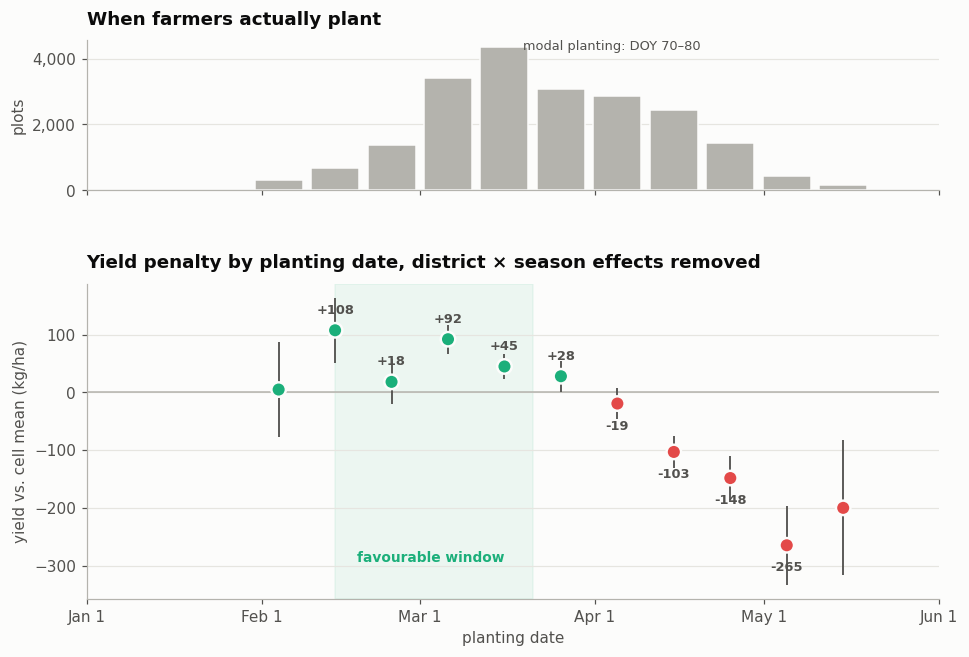

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6.6), sharex=True,
                         gridspec_kw={"height_ratios": [1, 2.1], "hspace": 0.40})

def doy_ticks(ax):
    ticks = [1, 32, 60, 91, 121, 152]
    ax.set_xticks(ticks)
    ax.set_xticklabels(["Jan 1", "Feb 1", "Mar 1", "Apr 1", "May 1", "Jun 1"])

ax = axes[0]
ax.bar(g.index + 5, g.n, width=8.5, color=MUTED, edgecolor=SURFACE, linewidth=1)
peak = g.n.idxmax()
ax.annotate(f"modal planting: DOY {peak}–{peak+10}", xy=(peak + 5, g.n.max()),
            xytext=(12, -2), textcoords="offset points", fontsize=8.5, color=INK2)
style(ax, "When farmers actually plant", None, "plots")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))

ax = axes[1]
ax.axhline(0, color=MUTED, lw=1)
colors = [AQUA if v >= 0 else RED for v in g.resid_mean]
ax.errorbar(g.index + 5, g.resid_mean, yerr=g.resid_se, fmt="none",
            ecolor=INK2, elinewidth=1.2, capsize=0, zorder=2)
ax.scatter(g.index + 5, g.resid_mean, s=90, c=colors, zorder=3,
           edgecolor=SURFACE, linewidth=1.6)
for x, v, n in zip(g.index + 5, g.resid_mean, g.n):
    if n >= 400:
        ax.annotate(f"{v:+.0f}", xy=(x, v), xytext=(0, 11 if v >= 0 else -17),
                    textcoords="offset points", ha="center", fontsize=8.5,
                    color=INK2, fontweight="bold")
ax.axvspan(45, 80, color=AQUA, alpha=0.07, zorder=0)
ax.annotate("favourable window", xy=(62, ax.get_ylim()[0] * 0.82),
            ha="center", fontsize=9, color=AQUA, fontweight="bold")
doy_ticks(ax)
style(ax, "Yield penalty by planting date, district × season effects removed",
      "planting date", "yield vs. cell mean (kg/ha)")
fig.tight_layout(); plt.show()

The two panels together are the actionable result. The yield-versus-date curve is
**flat from early February through mid-March and then falls monotonically** —
about −103 kg/ha for plots sown in the first half of April and −265 kg/ha for
those sown around the start of May, with no recovery.

But the top panel shows the modal planting date sits at day-of-year **70–80
(mid-March)**, on the shoulder of the plateau rather than in it, and a substantial
tail plants well into the penalty zone. The gap between where farmers plant and
where the curve peaks is the recommendation.

In [ ]:
import statsmodels.formula.api as smf

# A spline in DOY with district x season fixed effects. Nested specifications
# test whether the penalty is really about timing, or is a proxy for the fact
# that late planters are poorer and use fewer inputs.
pw["hybrid01"] = pw.uses_hybrid_seed
specs = {
    "1. timing only (district × season FE)":
        "yield_kg_ph ~ bs(plant_date_doy, df=5) + C(cell)",
    "2. + inputs (N, hybrid seed, plot size)":
        "yield_kg_ph ~ bs(plant_date_doy, df=5) + C(cell) + n_kg_ph + hybrid01 + plot_acres",
    "3. + wealth (wealth index, cattle)":
        "yield_kg_ph ~ bs(plant_date_doy, df=5) + C(cell) + n_kg_ph + hybrid01 + plot_acres"
        " + wealth_index + cows",
}
ref_cell = pw.cell.mode()[0]
rows, fitted = [], {}
for name, formula in specs.items():
    m = smf.ols(formula, data=pw).fit()
    fitted[name] = m
    grid = pd.DataFrame({"plant_date_doy": [55, 75, 90, 105, 120],
                         "cell": ref_cell, "n_kg_ph": pw.n_kg_ph.median(),
                         "hybrid01": 1.0, "plot_acres": pw.plot_acres.median(),
                         "wealth_index": 0.0, "cows": pw.cows.median()})
    p = m.predict(grid).to_numpy()
    rows.append(dict(spec=name, n=int(m.nobs), r2=m.rsquared,
                     **{f"DOY{d}": v for d, v in zip([75, 90, 105, 120], p[1:] - p[0])}))
pen = pd.DataFrame(rows)
print("Yield (kg/ha) relative to planting at DOY 55 (Feb 24), holding the cell fixed:\n")
print(pen.round(1).to_string(index=False))

# Crop-failure sensitivity: is the tail driven by total losses?
m_all = smf.ols(specs["1. timing only (district × season FE)"], data=pw).fit()
m_pos = smf.ols(specs["1. timing only (district × season FE)"],
                data=pw[pw[TARGET] > 100]).fit()
for lab, m, frame in [("all rows", m_all, pw), ("yield > 100 kg/ha", m_pos, pw[pw[TARGET] > 100])]:
    grid = pd.DataFrame({"plant_date_doy": [55, 120], "cell": frame.cell.mode()[0]})
    p = m.predict(grid).to_numpy()
    print(f"\n{lab:20s} n={int(m.nobs):5d}  DOY 120 vs DOY 55: {p[1]-p[0]:+.0f} kg/ha")

Yield (kg/ha) relative to planting at DOY 55 (Feb 24), holding the cell fixed:

                                   spec     n  r2  DOY75  DOY90  DOY105  DOY120
  1. timing only (district × season FE) 20863 0.3  -43.7 -155.4  -294.7  -420.1
2. + inputs (N, hybrid seed, plot size) 20863 0.3  -42.0 -125.4  -229.6  -324.7
     3. + wealth (wealth index, cattle) 16473 0.3  -51.9  -85.8  -180.0  -302.1

all rows             n=20863  DOY 120 vs DOY 55: -420 kg/ha

yield > 100 kg/ha    n=20562  DOY 120 vs DOY 55: -415 kg/ha


The penalty **survives every control**. Adding nitrogen, hybrid seed and plot size
absorbs roughly a quarter of it; adding wealth and cattle absorbs a little more;
what remains at day-of-year 120 is still about **−300 kg/ha**, roughly 10% of mean
yield. And it is not an artefact of crop failures — restricting to plots that
harvested anything at all leaves the estimate essentially unchanged.

The residual causal caveat is worth stating: farmers do not choose planting dates
at random, and a farmer who plants late may be doing so *because* the rains were
late on their particular farm. District × season fixed effects absorb the
district-wide version of that, but not a within-district, farm-level version. The
estimate should be read as a strong association with a plausible mechanism
(shorter effective season, flowering pushed into drier weather), not a
randomized-trial effect size.

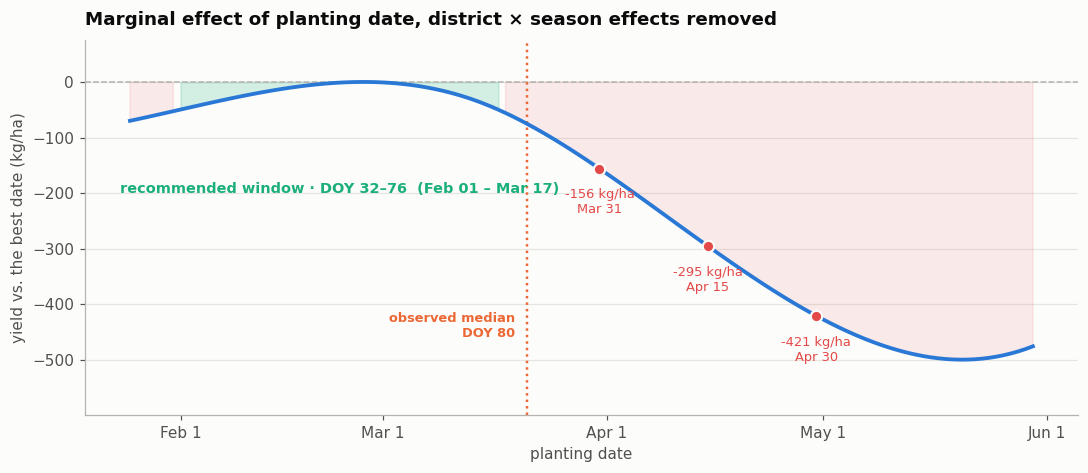

optimum      DOY 57  (Feb 26)
window within 50 kg/ha of the optimum: DOY 32-76  (Feb 01 - Mar 17)
observed median planting date:         DOY 80  (Mar 21)


In [ ]:
m = fitted["1. timing only (district × season FE)"]
grid = pd.DataFrame({"plant_date_doy": np.arange(25, 151),
                     "cell": ref_cell})
curve = m.predict(grid).to_numpy()
curve -= curve.max()
best_doy = int(grid.plant_date_doy[np.argmax(curve)])

fig, ax = plt.subplots(figsize=(10, 4.4))
ax.axhline(0, color=MUTED, lw=1, ls="--")
ax.plot(grid.plant_date_doy, curve, color=BLUE, lw=2.5, zorder=3)
inside = curve >= -50
ax.fill_between(grid.plant_date_doy, curve, 0, where=inside, color=AQUA, alpha=0.18)
ax.fill_between(grid.plant_date_doy, curve, 0, where=~inside, color=RED, alpha=0.10)
ax.set_ylim(curve.min() * 1.20, 75)

lo = int(grid.plant_date_doy[inside].min()); hi = int(grid.plant_date_doy[inside].max())
ax.annotate(f"recommended window · DOY {lo}–{hi}  "
            f"({pd.Timestamp('2021-01-01') + pd.Timedelta(days=lo-1):%b %d}"
            f" – {pd.Timestamp('2021-01-01') + pd.Timedelta(days=hi-1):%b %d})",
            xy=((lo + hi) / 2, ax.get_ylim()[0] * 0.30), ha="center", va="top",
            fontsize=9.5, color=AQUA, fontweight="bold")
for d in (90, 105, 120):
    v = curve[list(grid.plant_date_doy).index(d)]
    ax.scatter([d], [v], s=55, color=RED, zorder=4, edgecolor=SURFACE, linewidth=1.4)
    ax.annotate(f"{v:+.0f} kg/ha\n{pd.Timestamp('2021-01-01') + pd.Timedelta(days=d-1):%b %d}",
                xy=(d, v), xytext=(0, -13), textcoords="offset points",
                fontsize=8.5, color=RED, va="top", ha="center")

med = pw.plant_date_doy.median()
ax.axvline(med, color=ORANGE, lw=1.6, ls=":")
ax.annotate(f"observed median\nDOY {med:.0f}", xy=(med, curve.min() * 0.88),
            xytext=(-8, 0), textcoords="offset points", fontsize=8.5,
            color=ORANGE, fontweight="bold", ha="right", va="center")
ax.set_xticks([32, 60, 91, 121, 152])
ax.set_xticklabels(["Feb 1", "Mar 1", "Apr 1", "May 1", "Jun 1"])
style(ax, "Marginal effect of planting date, district × season effects removed",
      "planting date", "yield vs. the best date (kg/ha)")
fig.tight_layout(); plt.show()
def as_date(d):
    return f"{pd.Timestamp('2021-01-01') + pd.Timedelta(days=int(d)-1):%b %d}"
print(f"optimum      DOY {best_doy}  ({as_date(best_doy)})")
print(f"window within 50 kg/ha of the optimum: DOY {lo}-{hi}  "
      f"({as_date(lo)} - {as_date(hi)})")
print(f"observed median planting date:         DOY {med:.0f}  ({as_date(med)})")

In [ ]:
# Does aligning to the onset of rains beat the plain calendar? The plant-date-
# relative weather window in the feature file is monthly, so onset is derived
# from the first month whose cumulative rainfall from January crosses 100 mm.
mo     = ["jan", "feb", "mar", "apr", "may"]
starts = np.array([1, 32, 60, 91, 121])
cum    = np.cumsum(pw[[f"rain_mm_{m}" for m in mo]].to_numpy(), axis=1)
hit    = (cum >= 100)
pw["onset_doy"] = np.where(hit.any(1), starts[np.argmax(hit, axis=1)], np.nan)
pw["doy_minus_onset"] = pw.plant_date_doy - pw.onset_doy

print("within district × season correlation with yield:")
for v in ["plant_date_doy", "doy_minus_onset"]:
    r, n = within_group_corr(pw, v)
    print(f"  {v:18s} r = {r:+.4f}   (n = {n:,})")
print("\nonset month distribution:")
print(pw.onset_doy.map({1:'Jan',32:'Feb',60:'Mar',91:'Apr'}).value_counts().to_string())

within district × season correlation with yield:
  plant_date_doy     r = -0.0609   (n = 20,863)
  doy_minus_onset    r = -0.0692   (n = 20,863)

onset month distribution:
onset_doy
Feb    8979
Mar    6603
Jan    4642
Apr     639


Aligning planting to the onset of the rains gives **essentially no improvement**
over the plain calendar (*r* = −0.069 vs −0.061). That is a limitation of the data
rather than of the idea: onset can only be resolved to the nearest *month* from
monthly CHIRPS aggregates, and the effect being measured operates on a scale of
days. The honest conclusion is that **a calendar-based recommendation is what this
dataset supports**; testing a true onset-relative rule requires the daily CHIRPS
series, which `scripts/fetch_gee_weather.py` could fetch but currently aggregates
away.

In [ ]:
# Does the optimum move by district? A quadratic in DOY fitted per district on
# season-demeaned yield; districts whose fitted curve has no interior maximum
# (positive curvature) are reported as "no interior optimum" rather than forced.
rows = []
for dist_name, s in pw.groupby("district", observed=True):
    if len(s) < 300:
        continue
    s = s.copy()
    s["res"] = s[TARGET] - s.groupby("year")[TARGET].transform("mean")
    c = np.polyfit(s.plant_date_doy, s.res, 2)
    rows.append(dict(district=dist_name, n=len(s),
                     median_doy=s.plant_date_doy.median(),
                     opt_doy=(-c[1] / (2 * c[0])) if c[0] < 0 else np.nan))
opt = pd.DataFrame(rows)
opt["lateness"] = opt.median_doy - opt.opt_doy
interior = opt.dropna(subset=["opt_doy"]).query("20 <= opt_doy <= 160")
print(f"{len(interior)} of {len(opt)} large districts show an interior optimum")
print(f"median fitted optimum: DOY {interior.opt_doy.median():.0f}   "
      f"median observed planting: DOY {interior.median_doy.median():.0f}   "
      f"→ typical district plants {interior.lateness.median():.0f} days late\n")
print(interior.sort_values("lateness", ascending=False).round(1).to_string(index=False))

20 of 29 large districts show an interior optimum
median fitted optimum: DOY 68   median observed planting: DOY 81   → typical district plants 14 days late

      district   n  median_doy  opt_doy  lateness
     rachuonyo 547        80.0     33.3      46.7
       kabondo 506        81.5     36.2      45.3
           gem 947        87.0     49.3      37.7
          teso 749        80.0     45.2      34.8
        mumias 335        74.0     42.6      31.4
        butere 773        82.0     57.3      24.7
         alego 904        85.0     65.5      19.5
      kimilili 697        89.0     73.9      15.1
kakamega_south 709        75.0     60.2      14.8
        webuye 586        84.0     69.5      14.5
         kisii 361        73.0     58.9      14.1
       sirisia 673        83.0     71.2      11.8
        migori 695        75.0     64.7      10.3
         ndalu 774        97.0     88.4       8.6
         busia 916        90.0     82.4       7.6
        chwele 611        81.0     74.8    

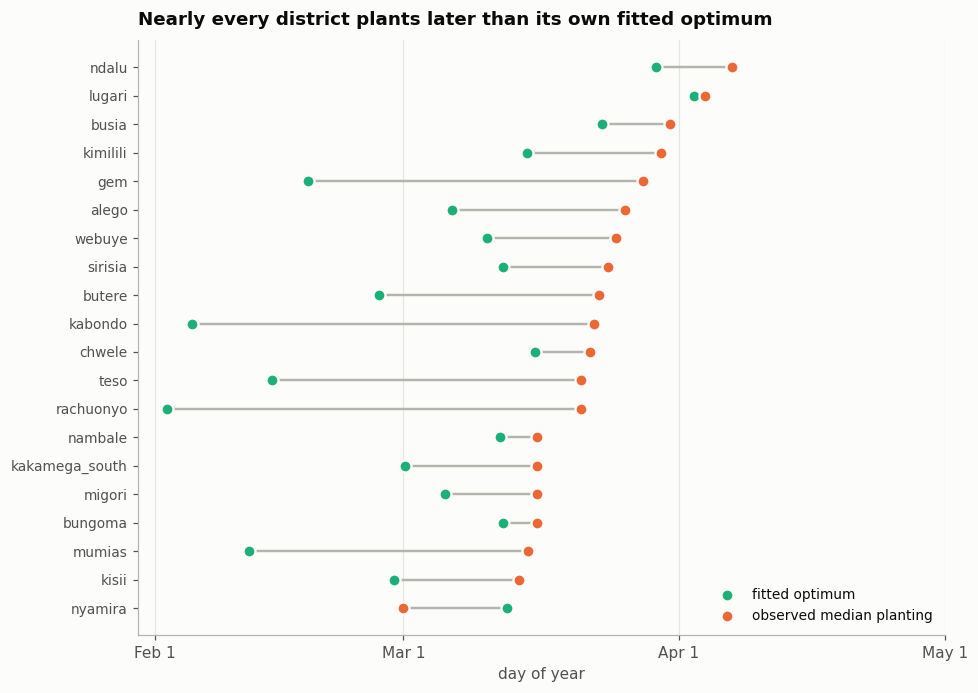

In [ ]:
d = interior.sort_values("median_doy")
yv = np.arange(len(d))
fig, ax = plt.subplots(figsize=(9, 6.4))
ax.hlines(yv, d.opt_doy, d.median_doy, color=MUTED, lw=1.6, zorder=1)
ax.scatter(d.opt_doy,    yv, s=62, color=AQUA, zorder=3, edgecolor=SURFACE,
           linewidth=1.5, label="fitted optimum")
ax.scatter(d.median_doy, yv, s=62, color=ORANGE, zorder=3, edgecolor=SURFACE,
           linewidth=1.5, label="observed median planting")
ax.set_yticks(yv); ax.set_yticklabels(d.district, fontsize=9)
ax.set_xticks([32, 60, 91, 121]); ax.set_xticklabels(["Feb 1", "Mar 1", "Apr 1", "May 1"])
style(ax, "Nearly every district plants later than its own fitted optimum",
      "day of year", xgrid=True, ygrid=False)
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout(); plt.show()

In [ ]:
# Aggregate size of the prize: counterfactually move every plot planted after
# DOY 75 back to DOY 75, holding its district x season cell fixed.
m = fitted["1. timing only (district × season FE)"]
obs  = m.predict(pw[["plant_date_doy", "cell"]])
alt  = m.predict(pw[["plant_date_doy", "cell"]].assign(
            plant_date_doy=np.clip(pw.plant_date_doy, None, 75)))
gain_kg = alt - obs
late = pw.plant_date_doy > 90
print(f"share of plots planted after DOY 90 (Mar 31): {late.mean():.1%}")
print(f"share planted after DOY 105 (Apr 15):        {(pw.plant_date_doy > 105).mean():.1%}\n")
print(f"mean gain, all dated plots      : {gain_kg.mean():+7.0f} kg/ha "
      f"({gain_kg.mean()/pw[TARGET].mean():+.1%} of mean yield)")
print(f"mean gain, plots planted late   : {gain_kg[late].mean():+7.0f} kg/ha "
      f"({gain_kg[late].mean()/pw.loc[late, TARGET].mean():+.1%} of their mean yield)")
# Scale check against the largest input lever, estimated the same way (same FE,
# same rows) so the two numbers are comparable rather than apples-to-oranges.
m_seed = smf.ols("yield_kg_ph ~ uses_hybrid_seed + C(cell)", data=pw).fit()
print(f"\nScale check — same district × season FE, same rows:")
print(f"  hybrid vs local seed            : "
      f"{m_seed.params['uses_hybrid_seed']:+7.0f} kg/ha")
print(f"  planting DOY 120 vs DOY 55      : "
      f"{pen.iloc[0]['DOY120']:+7.0f} kg/ha")

share of plots planted after DOY 90 (Mar 31): 34.6%
share planted after DOY 105 (Apr 15):        14.5%

mean gain, all dated plots      :     +98 kg/ha (+3.1% of mean yield)
mean gain, plots planted late   :    +247 kg/ha (+8.1% of their mean yield)

Scale check — same district × season FE, same rows:
  hybrid vs local seed            :    +753 kg/ha
  planting DOY 120 vs DOY 55      :    -420 kg/ha


**Roughly a third of plots are planted after March 31, and 15% after April 15.**
Moving just those plots into the favourable window is worth about **+250 kg/ha
each**, or **+98 kg/ha averaged across the whole population** — a ~3% yield lift
from a change that costs nothing but timing.

That is the single most valuable recommendation this dataset supports, and it is
worth noting *why* it is credible where the model's overall R² is only 0.12:
predicting an individual plot's yield is hard, but estimating the *average*
gradient of yield against a decision variable, with 21,000 observations and
fixed effects, is a much easier statistical problem.

## 7 · Conclusions and the recommended feature set

The zero-importance features identified in §5 are removable — but selecting them
using importance measured **on the holdout** and then reporting holdout R² would
be circular, and would report a number that cannot be reproduced on a genuinely
new season. So the selection is redone here against an **inner validation season**:
train on 2016–2018, measure permutation importance on 2019, select there, and only
then fit on 2016–2019 and score 2020. The holdout stays untouched by the
selection decision.

In [ ]:
INNER_VAL = 2019
inner_tr  = full.year < INNER_VAL
inner_va  = full.year == INNER_VAL

sel_model = make_model(**BEST)
sel_model.fit(X.loc[inner_tr, STABLE_EX], y[inner_tr])
sel_perm = permutation_importance(sel_model, X.loc[inner_va, STABLE_EX], y[inner_va],
                                  n_repeats=10, random_state=0, scoring="r2", n_jobs=1)
inner_imp = pd.Series(sel_perm.importances_mean, index=STABLE_EX).sort_values(ascending=False)
keep_final = inner_imp[inner_imp > 0].index.tolist()
print(f"selected on {INNER_VAL}: {len(keep_final)} of {len(STABLE_EX)} features "
      f"have positive importance\n")

_, r_full = evaluate(STABLE_EX,  "pruned ex-ante", **BEST)
_, r_trim = evaluate(keep_final, "trimmed",        **BEST)
print(f"ex-ante, η²-pruned      ({len(STABLE_EX):2d} features): "
      f"holdout R² = {r_full['holdout_r2']:+.4f}   MAE = {r_full['holdout_mae']:,.0f} kg/ha")
print(f"+ trimmed on {INNER_VAL}       ({len(keep_final):2d} features): "
      f"holdout R² = {r_trim['holdout_r2']:+.4f}   MAE = {r_trim['holdout_mae']:,.0f} kg/ha")

# For reference only: what the circular (holdout-selected) version would have
# claimed. The gap is the size of the optimism that protocol buys you.
leaky_set = imp[imp.perm_r2 > 0].index.tolist()
_, r_leak = evaluate(leaky_set, "holdout-selected", **BEST)
print(f"\n[reference — do not report] selecting on the holdout itself "
      f"({len(leaky_set)} features) would claim R² = {r_leak['holdout_r2']:+.4f}")

recommended = pd.DataFrame({
    "feature": keep_final,
    "role":  [ROLE[c] for c in keep_final],
    "tier":  [TIER[c] for c in keep_final],
    "year_var_share": [YVS[c] for c in keep_final],
    "inner_val_perm_r2": inner_imp[keep_final].values,
    "holdout_perm_r2":   imp.reindex(keep_final)["perm_r2"].values,
}).sort_values("inner_val_perm_r2", ascending=False)

out = FEATURES / "kenya_maize_recommended_features.csv"
recommended.to_csv(out, index=False)
print(f"\nwrote {out.relative_to(ROOT)}  ({len(recommended)} features)")
print(recommended.head(20).round(4).to_string(index=False))

selected on 2019: 29 of 66 features have positive importance

ex-ante, η²-pruned      (66 features): holdout R² = +0.1233   MAE = 1,145 kg/ha
+ trimmed on 2019       (29 features): holdout R² = +0.1136   MAE = 1,162 kg/ha

[reference — do not report] selecting on the holdout itself (28 features) would claim R² = +0.1257

wrote data\features\kenya_maize_recommended_features.csv  (29 features)
                 feature      role    tier  year_var_share  inner_val_perm_r2  holdout_perm_r2
                district condition ex_ante             NaN             0.1113           0.0771
               gdd10_feb condition ex_ante          0.0926             0.0254           0.0002
                 n_kg_ph     lever ex_ante          0.0384             0.0151           0.0131
               seed_type     lever ex_ante             NaN             0.0118           0.0125
             tmean_c_feb condition ex_ante          0.1535             0.0104           0.0000
              plot_acres condition 

**Trimming does not help, and the protocol is why we know that.** Selecting on an
honest inner validation season keeps 29 features and scores **+0.114** — slightly
*worse* than simply keeping all 66. Selecting on the holdout would have claimed
**+0.126** and looked like an improvement. The 1.2-point spread between those two
numbers is pure selection optimism, and it is larger than the effect being claimed.

So the recommendation is the **66-feature η²-pruned ex-ante set, untrimmed**. The
zero-importance features are harmless at depth 2 — a shallow model simply never
splits on them — and dropping them costs more through selection variance than it
saves. `kenya_maize_recommended_features.csv` is written for reference, ranked by
inner-validation importance, but it is a *diagnostic*, not a shorter feature list
to adopt.

### What the analysis established

**On correlation and confounding**

1. The strongest raw correlates of yield (*r* ≈ −0.33) are all **temperature and
   climate normals**, and they lose 80–95% of that association within a district.
   They are altitude proxies. They belong in the model as stratifiers and must
   never be read as agronomic advice.
2. The features that hold their correlation within district × season are, in
   order: **`hybrid_seed_share` (+0.205)**, **`uses_hybrid_seed` (+0.189)**,
   **`n_kg_ph` (+0.173)**, **`topdress_applied` (+0.169)**. Seed genetics first,
   then nitrogen — and specifically *whether* nitrogen was split across the
   season, not just how much was applied (`basal_n_share` is −0.107).
3. Confounding runs both ways: **compost's effect is masked** in the pooled
   correlation (+0.03) and triples within district (+0.09), because it is used
   disproportionately on poorer land.

**On feature importance and model design**

4. 150 features are perhaps **30–40 independent quantities**; the weather block
   is one very tight cluster and splits its importance across ~90 columns.
5. A naive ex-ante model scores **negative out-of-time R²**. Pruning features with
   year-variance share > 0.2 and capping tree depth at 2 takes it from **−0.040 to
   +0.123** — and at that point it **matches the model that also sees mid-season
   weather and shocks (+0.128)**. The recommendation surface costs no accuracy.
6. **`district` alone is ~60% of holdout performance.** The model's principal
   skill is knowing places, not agronomy. This is worth stating plainly to
   stakeholders, because a 0.12 R² headline hides that most of it is a lookup.
7. **Site-grouped CV is ~2.4× optimistic** (0.29 vs 0.12) because it still trains
   and validates within the same seasons. Report the out-of-time number.
8. **Feature selection on this data is not worth doing.** An honest inner-validation
   trim scores +0.114 against +0.123 for keeping everything; a holdout-selected trim
   would have claimed +0.126. Selection optimism (~0.012 R²) exceeds the available
   gain. Keep the 66-feature pruned set.

**On the planting window**

9. The favourable window is **roughly day-of-year 33–76 (early February to
   mid-March)**, with the fitted optimum at **DOY 57 (26 February)**, flat across
   that range and then falling monotonically: **−420 kg/ha by day 120** on timing
   alone, and still **−325 kg/ha** after controlling for nitrogen, hybrid seed and
   plot size. It is not an artefact of crop failures.
10. **Nearly every district plants later than its own fitted optimum**, by a median
   of about two weeks. A third of plots go in after March 31.
11. Moving late planters into the window is worth **~+250 kg/ha each, ~+98 kg/ha
    population-wide (≈3%)**.
12. Onset-relative timing did **not** beat the calendar here — but only because
    monthly rainfall cannot resolve onset to better than a month. This is the
    clearest next data investment.

### Recommended next steps

| Priority | Action |
|---|---|
| High | Adopt the pruned, depth-capped **ex-ante** specification as the recommendation model; report out-of-time R², never grouped CV. |
| High | Fetch **daily** CHIRPS in `fetch_gee_weather.py` to build a real onset-relative planting feature — the one place more data plausibly moves the planting result. |
| Medium | Collapse the weather block to a handful of representatives per cluster (§3) rather than shipping ~90 collinear columns. |
| Medium | Model `district` explicitly as a hierarchical / random effect rather than a 51-level categorical, so new districts degrade gracefully instead of falling back to a global mean. |
| Medium | Treat the recommendation layer as **two separate products**: a *timing* rule (well-identified, large, free) and a *yield forecast* (weak at plot level, adequate at district level). Do not ship the second as if it were the first. |
| Low | Revisit `basal_n_share` and `topdress_applied` as a paired treatment recommendation — the split of nitrogen looks more actionable than the total. |